In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

from pydose_rt.data import MachineConfig, Phantom, Beam
from pydose_rt import DoseEngine

In [2]:
machine_config = MachineConfig(preset="../src/pydose_rt/data/machine_presets/lund-probe.json")

phantom_shape = (100, 100, 100)
phantom_resolution = (2.0, 2.0, 2.0)
phantom = Phantom.from_uniform_water(shape=phantom_shape, spacing=phantom_resolution)

device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

In [3]:
beam = Beam.create(0.0, 60, 0.0, (100.0, 100.0))
beam.mu = 130 * beam.mu

phantom=phantom.to(device).to(dtype)
beam = beam.to(device).to(dtype)

dose_engine = DoseEngine(machine_config, kernel_size=101, image_template=phantom.density_image, beam_template=beam)

dose = dose_engine.compute_dose(beam, ct_image=phantom.density_image)

/home/bolo/Documents/PyDoseRT/src/pydose_rt/geometry/projections.py:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


torch.Size([1, 100, 100, 100])


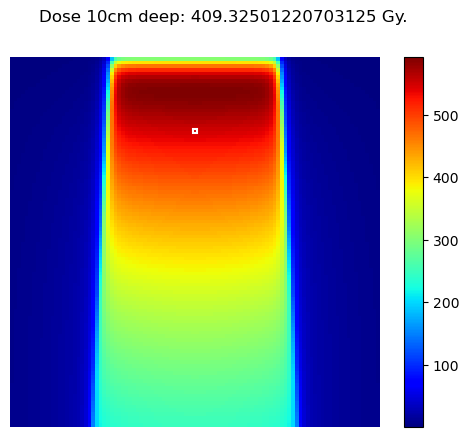

Recommended mean avg. 0.0022312121000140905


In [4]:

slice_idx = 84
print(dose.shape)

fig, ax = plt.subplots()
im = ax.imshow(dose[0, 50, :, :].cpu().detach().numpy(), cmap='jet', vmin=np.min(dose.cpu().detach().numpy()), vmax=np.max(dose.cpu().detach().numpy()), interpolation='nearest')


plt.suptitle(f"Dose 10cm deep: {np.round(dose[0, 50, 50, 50].detach().cpu().numpy(), 3)} Gy.")
# Add a rectangle around [25, 64]
rect = patches.Rectangle((50 - 1, 20 - 1), 1, 1, linewidth=1.5, edgecolor='white', facecolor='none')
ax.add_patch(rect)

ax.axis('off')
plt.colorbar(im, ax=ax)
plt.show()
print(f"Recommended mean avg. {machine_config.mean_photon_energy_MeV / dose[0, 50, 50, 50]}")

In [5]:
dose_engine.calibrate(130)
dose = dose_engine.compute_dose(beam, ct_image=phantom.density_image)

Calibration failed. Adjusting calibration factor to: 0.002225330332004112


torch.Size([1, 100, 100, 100])


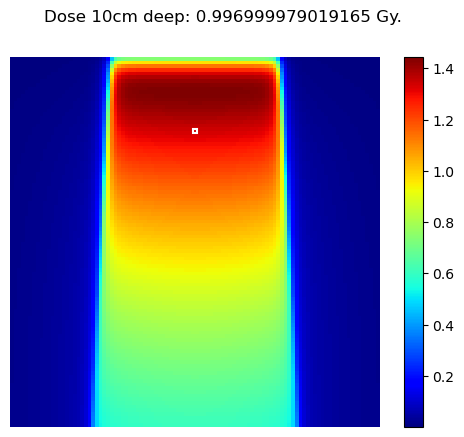

Recommended mean avg. 0.0022312121000140905


In [6]:

slice_idx = 84
print(dose.shape)

fig, ax = plt.subplots()
im = ax.imshow(dose[0, 50, :, :].cpu().detach().numpy(), cmap='jet', vmin=np.min(dose.cpu().detach().numpy()), vmax=np.max(dose.cpu().detach().numpy()), interpolation='nearest')


plt.suptitle(f"Dose 10cm deep: {np.round(dose[0, 50, 50, 50].detach().cpu().numpy(), 3)} Gy.")
# Add a rectangle around [25, 64]
rect = patches.Rectangle((50 - 1, 20 - 1), 1, 1, linewidth=1.5, edgecolor='white', facecolor='none')
ax.add_patch(rect)

ax.axis('off')
plt.colorbar(im, ax=ax)
plt.show()
print(f"Recommended mean avg. {machine_config.mean_photon_energy_MeV / dose[0, 50, 50, 50]}")